In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/blood_samples_dataset.csv')
df.head()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.001827,0.033693,0.114755,0.997927,0.562604,0.866499,0.578042,0.914615,0.026864,0.038641,...,0.653230,0.186104,0.430398,0.016678,0.885352,0.652733,0.788235,0.054788,0.031313,Thalasse
1,0.436679,0.972653,0.084998,0.180909,0.675736,0.563889,0.798382,0.670361,0.376092,0.184890,...,0.833540,0.153001,0.458533,0.401845,0.635969,0.574425,0.047025,0.607985,0.594123,Diabetes
2,0.545697,0.324815,0.584467,0.475748,0.558596,0.661007,0.934056,0.381782,0.500342,0.531829,...,0.678901,0.220479,0.817151,0.690981,0.101633,0.855740,0.551124,0.413294,0.070909,Heart Di
3,0.172994,0.050351,0.736000,0.782022,0.069435,0.085219,0.032907,0.460619,0.785448,0.491495,...,0.381500,0.459396,0.420154,0.798537,0.399236,0.324600,0.499504,0.436662,0.242766,Diabetes
4,0.758534,0.739968,0.597868,0.772683,0.875720,0.860265,0.486189,0.486686,0.621048,0.191756,...,0.993381,0.272338,0.663579,0.265227,0.918847,0.804910,0.571119,0.188368,0.750848,Heart Di


In [3]:
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

print("\nInformation about DataFrame (including data types and non-null counts):")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())


Descriptive Statistics for Numerical Columns:
          Glucose  Cholesterol  Hemoglobin   Platelets  White Blood Cells  \
count  486.000000   486.000000  486.000000  486.000000         486.000000   
mean     0.490044     0.506797    0.485502    0.528136           0.509783   
std      0.284196     0.282871    0.298818    0.292610           0.290887   
min      0.001827     0.003088    0.000719    0.000006          -0.000206   
25%      0.236664     0.268021    0.201994    0.276155           0.264944   
50%      0.496471     0.502397    0.477706    0.538642           0.511102   
75%      0.727144     0.754638    0.750028    0.789486           0.767896   
max      0.991742     0.999606    0.997876    0.999507           0.999646   

       Red Blood Cells  Hematocrit  Mean Corpuscular Volume  \
count       486.000000  486.000000               486.000000   
mean          0.504347    0.501042                 0.516185   
std           0.302865    0.294501                 0.279954   
min    

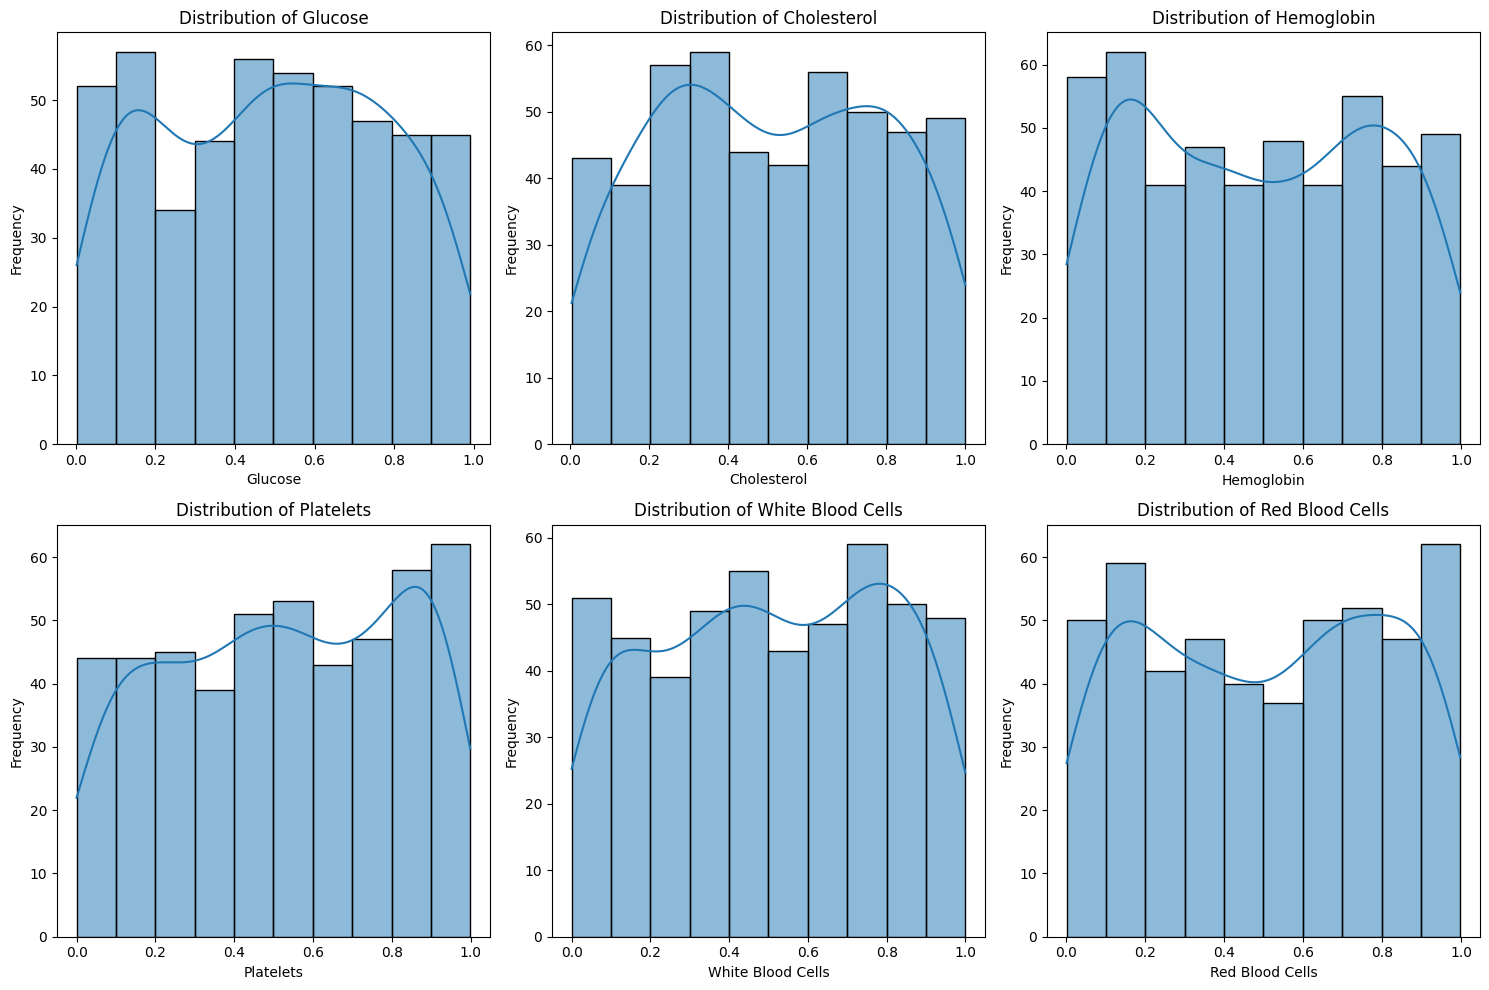

To explore all numerical columns, we can extend the loop or use a different visualization approach.


In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols[:6]): # Limiting to first 6 for brevity, can adjust as needed
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("To explore all numerical columns, we can extend the loop or use a different visualization approach.")

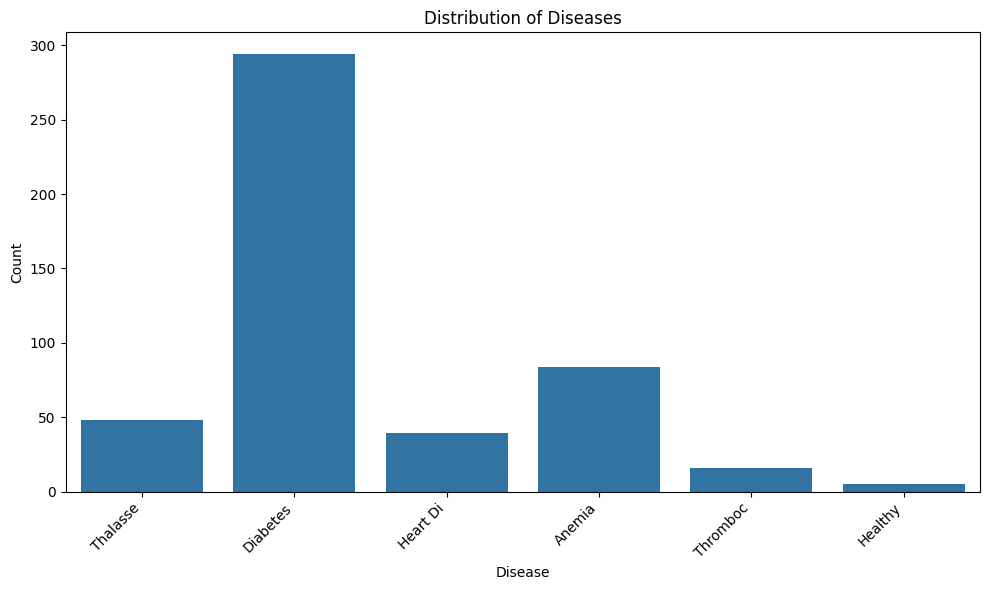

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Disease')
plt.title('Distribution of Diseases')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows = initial_rows - df.shape[0]

if duplicate_rows > 0:
    print(f"Removed {duplicate_rows} duplicate rows.")
else:
    print("No duplicate rows found.")

print(f"DataFrame now has {df.shape[0]} rows and {df.shape[1]} columns.")

No duplicate rows found.
DataFrame now has 486 rows and 25 columns.


In [7]:
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df.drop('Disease', axis=1)
y = df['Disease']

# Encode the target variable 'Disease'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original 'Disease' column unique values:", y.unique())
print("Encoded 'Disease' column unique values:", np.unique(y_encoded))
print("Mapping of original to encoded values:", list(label_encoder.classes_))
print("Shape of features (X):", X.shape)
print("Shape of encoded target (y_encoded):", y_encoded.shape)

Original 'Disease' column unique values: ['Thalasse' 'Diabetes' 'Heart Di' 'Anemia' 'Thromboc' 'Healthy']
Encoded 'Disease' column unique values: [0 1 2 3 4 5]
Mapping of original to encoded values: ['Anemia', 'Diabetes', 'Healthy', 'Heart Di', 'Thalasse', 'Thromboc']
Shape of features (X): (486, 24)
Shape of encoded target (y_encoded): (486,)


In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (388, 24)
Shape of X_test: (98, 24)
Shape of y_train: (388,)
Shape of y_test: (98,)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np # Ensure numpy is imported for np.arange

# Initialize a dictionary to hold the models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(random_state=42)
}

results = {}

print("\n--- Training and Evaluating Models ---")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    # Fix: Specify 'labels' to ensure all classes are accounted for, even if not in y_test/y_pred
    report = classification_report(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_)

    results[name] = {'Accuracy': accuracy, 'Classification Report': report}

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for {name}:\n{report}")

print("\n--- Model Comparison ---")
best_accuracy = 0
best_model = ''

for name, metrics in results.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.4f}")
    if metrics['Accuracy'] > best_accuracy:
        best_accuracy = metrics['Accuracy']
        best_model = name

print(f"\nTop Performing Model: {best_model} with an Accuracy of {best_accuracy:.4f}")


--- Training and Evaluating Models ---

Training Logistic Regression...
Logistic Regression Accuracy: 0.6531
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Anemia       0.58      0.35      0.44        20
    Diabetes       0.70      0.92      0.79        59
     Healthy       0.00      0.00      0.00         0
    Heart Di       0.00      0.00      0.00         7
    Thalasse       0.33      0.22      0.27         9
    Thromboc       1.00      0.33      0.50         3

    accuracy                           0.65        98
   macro avg       0.44      0.30      0.33        98
weighted avg       0.60      0.65      0.61        98


Training Decision Tree Classifier...
Decision Tree Classifier Accuracy: 0.9694
Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

      Anemia       0.95      1.00      0.98        20
    Diabetes       0.98      1.00      0.99        59
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Random Forest Classifier Accuracy: 0.9082
Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

      Anemia       0.94      0.85      0.89        20
    Diabetes       0.89      1.00      0.94        59
     Healthy       0.00      0.00      0.00         0
    Heart Di       1.00      0.43      0.60         7
    Thalasse       0.89      0.89      0.89         9
    Thromboc       1.00      0.67      0.80         3

    accuracy                           0.91        98
   macro avg       0.79      0.64      0.69        98
weighted avg       0.91      0.91      0.90        98


Training Gradient Boosting Classifier...
Gradient Boosting Classifier Accuracy: 0.9592
Classification Report for Gradient Boosting Classifier:
              precision    recall  f1-score   support

      Anemia       0.95      0.95      0.95        20
    Diabetes       1.00      0.98      0.99        59
     Healthy       0.00      0.00      0.00         0
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("\n--- Hyperparameter Tuning for Decision Tree Classifier ---")

# Define the parameter grid for Decision Tree Classifier
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Evaluate the best estimator on the test set
best_dt_model = grid_search.best_estimator_
y_pred_tuned = best_dt_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_report = classification_report(y_test, y_pred_tuned, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_)

print(f"\nAccuracy of Tuned Decision Tree Classifier on Test Set: {tuned_accuracy:.4f}")
print(f"Classification Report for Tuned Decision Tree Classifier:\n{tuned_report}")


--- Hyperparameter Tuning for Decision Tree Classifier ---
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-validation Accuracy: 0.9305

Accuracy of Tuned Decision Tree Classifier on Test Set: 0.9592
Classification Report for Tuned Decision Tree Classifier:
              precision    recall  f1-score   support

      Anemia       0.95      1.00      0.98        20
    Diabetes       0.98      1.00      0.99        59
     Healthy       0.00      0.00      0.00         0
    Heart Di       0.71      0.71      0.71         7
    Thalasse       1.00      0.78      0.88         9
    Thromboc       1.00      1.00      1.00         3

    accuracy                           0.96        98
   macro avg       0.78      0.75      0.76        98
weighted avg       0.96      0.96      0.96        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

<Figure size 1000x800 with 0 Axes>

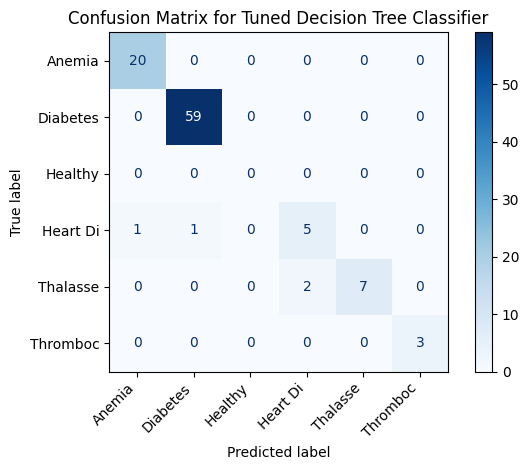

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate the best estimator on the test set (using the tuned model)
y_pred_tuned = best_dt_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=np.arange(len(label_encoder.classes_)))

# Display the confusion matrix
plt.figure(figsize=(10, 8))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Decision Tree Classifier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Inverse transform the encoded test set and predictions to get original disease names
actual_diseases = label_encoder.inverse_transform(y_test)
predicted_diseases = label_encoder.inverse_transform(y_pred_tuned)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Disease': actual_diseases,
    'Predicted Disease': predicted_diseases
})

# Optionally, add some features from X_test to the comparison_df for context
# For simplicity, let's add a few key features. You can customize this.
comparison_df = pd.concat([X_test[['Glucose', 'Cholesterol', 'Hemoglobin']].reset_index(drop=True), comparison_df], axis=1)

print("\n--- Model Predictions vs. Actual Values (First 10 entries) ---")
print(comparison_df.head(10))


--- Model Predictions vs. Actual Values (First 10 entries) ---
    Glucose  Cholesterol  Hemoglobin Actual Disease Predicted Disease
0  0.570437     0.434672    0.627588         Anemia            Anemia
1  0.752313     0.625857    0.835187         Anemia            Anemia
2  0.082057     0.314009    0.838758       Heart Di          Diabetes
3  0.974915     0.774048    0.834563       Diabetes          Diabetes
4  0.012944     0.544329    0.597535       Diabetes          Diabetes
5  0.753615     0.753903    0.319535       Diabetes          Diabetes
6  0.715000     0.938710    0.945782       Diabetes          Diabetes
7  0.442670     0.296375    0.650275       Diabetes          Diabetes
8  0.040890     0.537565    0.150853       Thromboc          Thromboc
9  0.414942     0.188922    0.081124       Diabetes          Diabetes
